# Diffusion SR — ASIP from AMSR2
Loads models via `diffusion_model.py`, plots training history, and runs inference.

**Sections**
1. Config & imports
2. Load models
3. Training history
4. Inference — 5-panel plot
5. Multi-sample uncertainty
6. CRPS & reliability diagram

## 1 — Config & imports

In [1]:
import os, sys, json, itertools, warnings
warnings.filterwarnings('ignore')
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

# ── Edit these to match your training script ──────────────────────────────────
postfix = '5'   # fusion model version used as conditioning

CODE_DIR         = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/Code'
CACHE_DIR        = '/dmidata/projects/asip-cms/ninna_msc/zarr_cache'
FUSION_CKPT_BASE = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/outputs/training'
OUTPUT_DIR       = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/outputs/diffusion'

# ── Inference settings ────────────────────────────────────────────────────────
NUM_STEPS  = 500   # denoising steps (use 100 for a quick preview)
SAMPLE_IDX = 2     # which item in the batch to visualise
N_SAMPLES  = 20    # samples for uncertainty estimation

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')
print(f'Device: {device}')

# ── Import from diffusion_model.py ────────────────────────────────────────────
# diffusion_model.py is the single source of truth for SIGMA and SIC_SENTINEL_MIN
sys.path.insert(0, CODE_DIR)
from lib.model.diffusion_model import (
    load_models, Euler_Maruyama_sampler,
    prepare_cond, prepare_sic, valid_mask,
    SIGMA, SIC_SENTINEL_MIN,
)
from lib.model.FusionNetASPP import FusionNetASPP as mdl
from lib.dataset.dataloader  import AMSR2Dataset, collate_pad_to_max

# ── Derived paths — mirror training script exactly ────────────────────────────
DIFF_CKPT    = f'{OUTPUT_DIR}/ckpt_{mdl.name.lower()}_{postfix}.pth'
BEST_CKPT    = f'{OUTPUT_DIR}/best_ckpt_{mdl.name.lower()}_{postfix}.pth'
HISTORY_PATH = f'{OUTPUT_DIR}/history_{mdl.name.lower()}_{postfix}.json'
SAMPLE_PATH  = f'{OUTPUT_DIR}/samples_{mdl.name.lower()}_{postfix}_idx{SAMPLE_IDX}.npz'

# print(f'SIGMA            : {SIGMA}')
# print(f'SIC_SENTINEL_MIN : {SIC_SENTINEL_MIN}')
# print(f'Diff ckpt        : {DIFF_CKPT}')
# print(f'Best ckpt        : {BEST_CKPT}')

Device: cuda


## 2 — Load models

In [2]:
# # ── Remove corrupted best checkpoint if too small ─────────────────────────────
# if os.path.exists(BEST_CKPT) and os.path.getsize(BEST_CKPT) < 1_000_000:
#     print(f'Corrupted best checkpoint ({os.path.getsize(BEST_CKPT)} bytes) — removing.')
#     os.remove(BEST_CKPT)

fusion_model, score_model, mdl_cls, marginal_prob_std_fn, diffusion_coeff_fn, fusion_info, diff_info = \
    load_models(
        code_dir         = CODE_DIR,
        fusion_ckpt_base = FUSION_CKPT_BASE,
        postfix          = postfix,
        diff_ckpt        = DIFF_CKPT,
        best_ckpt        = BEST_CKPT,
        device           = device,
    )

val_dataset = AMSR2Dataset(CACHE_DIR, split='val')
val_loader  = DataLoader(
    val_dataset, batch_size=32, shuffle=False,
    num_workers=4, pin_memory=False,
    collate_fn=collate_pad_to_max,
)
print(f'Val: {len(val_dataset)} samples')

FusionNetASPP  epoch=214  val_rmse=5.86%
ScoreNet: loaded EMA weights from /dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/outputs/diffusion/best_ckpt_fusionnetaspp_5.pth
ScoreNet: epoch=251  train=0.00560  val=0.00664  ema_val=0.00620
Val: 10000 samples


## 3 — Training history

In [3]:
# ── Experiment summary ────────────────────────────────────────────────────────
_h = {}
if os.path.exists(HISTORY_PATH):
    with open(HISTORY_PATH) as f:
        _h = json.load(f)

inner            = score_model.module if hasattr(score_model, 'module') else score_model
total_params     = sum(p.numel() for p in inner.parameters())
trainable_params = sum(p.numel() for p in inner.parameters() if p.requires_grad)

n_epochs_trained = len(_h.get('epoch', []))
last_epoch       = _h['epoch'][-1]      if _h.get('epoch')           else 'N/A'
_ema             = _h.get('ema_val_loss', [])
best_ema         = min(_ema)            if _ema                       else float('nan')
best_epoch_idx   = _ema.index(best_ema) if _ema                       else None
best_epoch       = _h['epoch'][best_epoch_idx] if best_epoch_idx is not None else 'N/A'
infer_ckpt       = BEST_CKPT if os.path.exists(BEST_CKPT) else DIFF_CKPT

print('=' * 54)
print('  EXPERIMENT SUMMARY')
print('=' * 54)
print(f"  Conditioning model : {mdl_cls.name}  (postfix={postfix})")
print(f"  Fusion val RMSE    : {fusion_info['val_rmse']:.2f}%  (epoch {fusion_info['epoch']})")
print('-' * 54)
print('  ScoreNet architecture')
print(f'    Total params     : {total_params:,}')
print(f'    Trainable params : {trainable_params:,}')
print(f'    Channels         : (32, 64, 128, 256)')
print(f'    Bottleneck attn  : SpatialSelfAttention (8 heads)')
print(f'    Conditioning     : input concatenation [x, y]')
print('-' * 54)
print('  Training')
print(f'    SIGMA            : {SIGMA}  (data normalised to [0,1])')
print(f'    SIC sentinel     : values >= {SIC_SENTINEL_MIN} masked')
print(f'    Epochs trained   : {n_epochs_trained}  (last epoch: {last_epoch})')
print(f'    Best ema_val     : {best_ema:.5f}  at epoch {best_epoch}')
if _h.get('train_loss'):
    print(f"    Latest train     : {_h['train_loss'][-1]:.5f}")
    print(f"    Latest val       : {_h['val_loss'][-1]:.5f}")
    print(f"    Latest ema_val   : {_h['ema_val_loss'][-1]:.5f}")
    print(f"    Latest LR        : {_h['lr'][-1]:.2e}")
print('-' * 54)
print('  Inference')
print(f'    Device           : {device}')
print(f'    Num steps        : {NUM_STEPS}')
print(f'    Checkpoint       : {os.path.basename(infer_ckpt)}')
print('=' * 54)

  EXPERIMENT SUMMARY
  Conditioning model : FusionNetASPP  (postfix=5)
  Fusion val RMSE    : 5.86%  (epoch 214)
------------------------------------------------------
  ScoreNet architecture
    Total params     : 1,378,433
    Trainable params : 1,378,305
    Channels         : (32, 64, 128, 256)
    Bottleneck attn  : SpatialSelfAttention (8 heads)
    Conditioning     : input concatenation [x, y]
------------------------------------------------------
  Training
    SIGMA            : 5.0  (data normalised to [0,1])
    SIC sentinel     : values >= 254 masked
    Epochs trained   : 259  (last epoch: 258)
    Best ema_val     : 0.00620  at epoch 251
    Latest train     : 0.00539
    Latest val       : 0.00654
    Latest ema_val   : 0.00667
    Latest LR        : 1.25e-04
------------------------------------------------------
  Inference
    Device           : cuda
    Num steps        : 500
    Checkpoint       : best_ckpt_fusionnetaspp_5.pth


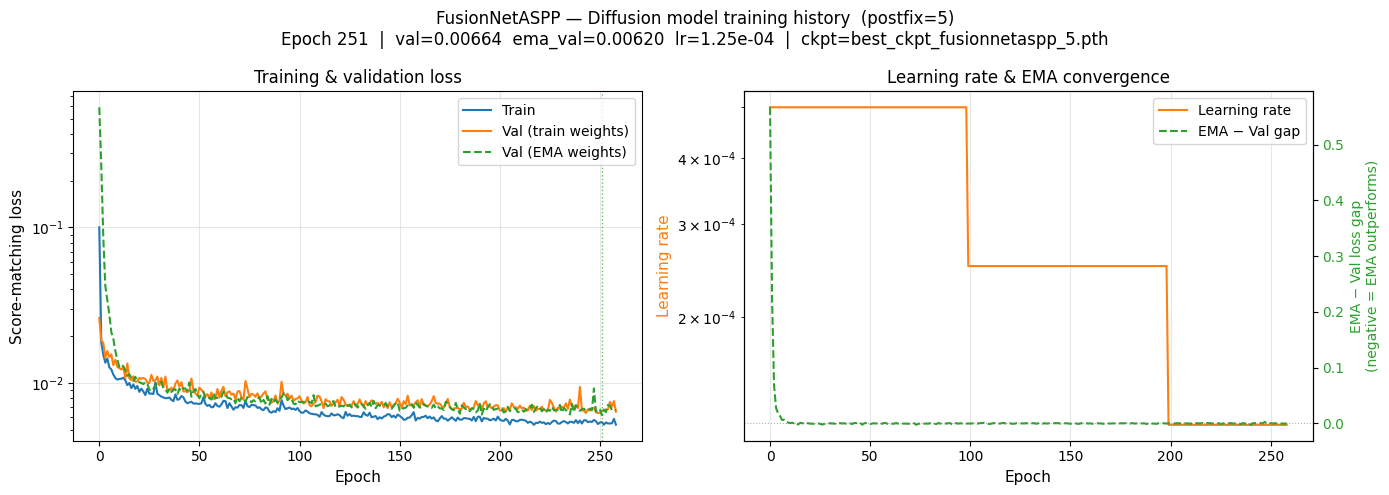

Epochs trained : 259  (latest: 258)
Best ema_val   : 0.00620  at epoch 251
Latest train   : 0.00539
Latest val     : 0.00654
Latest ema_val : 0.00667
EMA gap        : +0.00013  (EMA still converging)


In [6]:
if not _h:
    print('No history file found — run training first.')
else:
    epochs     = _h['epoch']
    train_loss = _h['train_loss']
    val_loss   = _h['val_loss']
    ema_loss   = _h.get('ema_val_loss', [])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Left: loss curves ─────────────────────────────────────────────────────
    axes[0].plot(epochs, train_loss, label='Train',               linewidth=1.5, color='tab:blue')
    axes[0].plot(epochs, val_loss,   label='Val (train weights)', linewidth=1.5, color='tab:orange')
    if ema_loss:
        axes[0].plot(epochs, ema_loss, label='Val (EMA weights)', linewidth=1.5,
                     linestyle='--', color='tab:green')
        best_idx = int(np.argmin(ema_loss))
        axes[0].axvline(epochs[best_idx], color='tab:green', linestyle=':', linewidth=1, alpha=0.7)
        # axes[0].annotate(f'Best EMA\nepoch {epochs[best_idx]}',
        #                  xy=(epochs[best_idx], ema_loss[best_idx]),
        #                  xytext=(epochs[best_idx] + max(epochs) * 0.03, ema_loss[best_idx] * 1.5),
        #                  fontsize=8, color='tab:green',
        #                  arrowprops=dict(arrowstyle='->', color='tab:green', lw=0.8))
    axes[0].set_xlabel('Epoch', fontsize=11)
    axes[0].set_ylabel('Score-matching loss', fontsize=11)
    axes[0].set_title('Training & validation loss', fontsize=12)
    axes[0].legend(loc='upper right', fontsize=10)
    axes[0].grid(True, alpha=0.3)
    if len(epochs) > 10:
        axes[0].set_yscale('log')

    # ── Right: LR + EMA gap ───────────────────────────────────────────────────
    ln1 = axes[1].plot(epochs, _h['lr'], color='tab:orange', linewidth=1.5, label='Learning rate')
    axes[1].set_xlabel('Epoch', fontsize=11)
    axes[1].set_ylabel('Learning rate', fontsize=11, color='tab:orange')
    axes[1].tick_params(axis='y', labelcolor='tab:orange')
    axes[1].set_yscale('log')
    axes[1].set_title('Learning rate & EMA convergence', fontsize=12)
    axes[1].grid(True, alpha=0.3)

    if ema_loss:
        ax2     = axes[1].twinx()
        ema_gap = [e - v for e, v in zip(ema_loss, val_loss)]
        ln2     = ax2.plot(epochs, ema_gap, color='tab:green', linewidth=1.5,
                           linestyle='--', label='EMA − Val gap')
        ax2.axhline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
        ax2.set_ylabel('EMA − Val loss gap\n(negative = EMA outperforms)', fontsize=10,
                       color='tab:green')
        ax2.tick_params(axis='y', labelcolor='tab:green')
        lns  = ln1 + ln2
        labs = [l.get_label() for l in lns]
        ax2.legend(lns, labs, loc='upper right', fontsize=10)

    _epoch     = diff_info['epoch']
    _val       = diff_info['val_loss']
    _ema_val   = diff_info['ema_val_loss']
    _lr        = _h['lr'][_h['epoch'].index(_epoch)] if _epoch in _h['epoch'] else float('nan')
    _ckpt_name = os.path.basename(BEST_CKPT if os.path.exists(BEST_CKPT) else DIFF_CKPT)
    subtitle   = (f'Epoch {_epoch}  |  val={_val:.5f}  ema_val={_ema_val:.5f}  '
                  f'lr={_lr:.2e}  |  ckpt={_ckpt_name}')

    plt.suptitle(f'{mdl_cls.name} — Diffusion model training history  (postfix={postfix})\n{subtitle}',
                 fontsize=12)
    plt.tight_layout()
    plt.show()

    ref        = ema_loss if ema_loss else val_loss
    best_idx   = int(np.argmin(ref))
    print(f'Epochs trained : {len(epochs)}  (latest: {epochs[-1]})')
    print(f'Best ema_val   : {min(ref):.5f}  at epoch {epochs[best_idx]}')
    print(f'Latest train   : {train_loss[-1]:.5f}')
    print(f'Latest val     : {val_loss[-1]:.5f}')
    if ema_loss:
        print(f'Latest ema_val : {ema_loss[-1]:.5f}')
        print(f'EMA gap        : {ema_gap[-1]:+.5f}  '
              f'({"EMA outperforms" if ema_gap[-1] < 0 else "EMA still converging"})')

## 4 - Score diagnostic

In [8]:
# ── Load a validation batch ───────────────────────────────────────────────────
amsr2, sic, mask = next(itertools.islice(val_loader, 1, None))
amsr2 = amsr2.to(device)
sic   = sic.to(device)
mask  = mask.to(device)

with torch.no_grad():
    y      = fusion_model(amsr2, target_size=(sic.shape[-2], sic.shape[-1]))
    y_cond = prepare_cond(y)   # normalised to [0,1]

valid_sic = sic[(~torch.isnan(sic)) & (sic < SIC_SENTINEL_MIN)]
print(f'Batch          : {sic.shape}')
print(f'Valid SIC      : {valid_sic.min():.1f} → {valid_sic.max():.1f}  mean={valid_sic.mean():.1f}')
print(f'Condition [01] : {y_cond.min():.4f} → {y_cond.max():.4f}')   # must be [0,1]

# ── Score function check ──────────────────────────────────────────────────────
with torch.no_grad():
    t_test     = torch.ones(1, device=device)
    std_test   = marginal_prob_std_fn(t_test)
    x_test     = torch.randn(1, 1, y_cond.shape[-2], y_cond.shape[-1], device=device) * std_test
    score_test = score_model(x_test, t_test, y_cond[:1])

print(f'\nSIGMA          : {SIGMA}  →  std at t=1: {std_test.item():.4f}')
print(f'score range    : {score_test.min():.4f} → {score_test.max():.4f}')
print(f'score std      : {score_test.std():.4f}')
print()
if score_test.std() < 0.01:
    print('⚠ Score std is near zero — model may be collapsed. Check SIGMA and checkpoint.')
elif y_cond.max() > 1.01:
    print('⚠ Condition is not normalised to [0,1] — check prepare_cond().')
else:
    print('✓ Looks healthy — proceed to sampling.')

Batch          : torch.Size([32, 1, 214, 212])
Valid SIC      : 0.0 → 100.0  mean=72.0
Condition [01] : 0.0000 → 1.0000

SIGMA          : 5.0  →  std at t=1: 2.7306
score range    : -1.4201 → 1.5744
score std      : 0.3644

✓ Looks healthy — proceed to sampling.


## 5 — Inference — 5-panel plot
Two independent diffusion samples from the same FusionNet condition.

In [9]:
print('Sample #1 ...')
x_estim  = Euler_Maruyama_sampler(
    score_model, marginal_prob_std_fn, diffusion_coeff_fn,
    y_cond, batch_size=sic.shape[0], num_steps=NUM_STEPS, device=str(device),
)
print('Sample #2 ...')
x_estim2 = Euler_Maruyama_sampler(
    score_model, marginal_prob_std_fn, diffusion_coeff_fn,
    y_cond, batch_size=sic.shape[0], num_steps=NUM_STEPS, device=str(device),
)
print('Done.')

# Raw output check — samples in [0,1], mean ~0.4 for typical Arctic scene
raw = x_estim[SAMPLE_IDX, 0].detach().cpu().numpy()
print(f'Raw output: {raw.min():.3f} → {raw.max():.3f}  mean={raw.mean():.3f}')

# Save for fast replotting
np.savez(
    SAMPLE_PATH,
    x_estim  = x_estim[SAMPLE_IDX,  0].detach().cpu().numpy(),
    x_estim2 = x_estim2[SAMPLE_IDX, 0].detach().cpu().numpy(),
    sic_raw  = sic[SAMPLE_IDX, 0].cpu().numpy(),
    y_raw    = y[SAMPLE_IDX, 0].detach().cpu().numpy(),
    mask_raw = mask[SAMPLE_IDX, 0].cpu().numpy(),
)
print(f'Samples saved → {SAMPLE_PATH}')

Sample #1 ...


Sample #2 ...


Done.
Raw output: -0.117 → 1.224  mean=0.369
Samples saved → /dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/outputs/diffusion/samples_fusionnetaspp_5_idx2.npz


Loaded from /dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/outputs/diffusion/samples_fusionnetaspp_5_idx2.npz


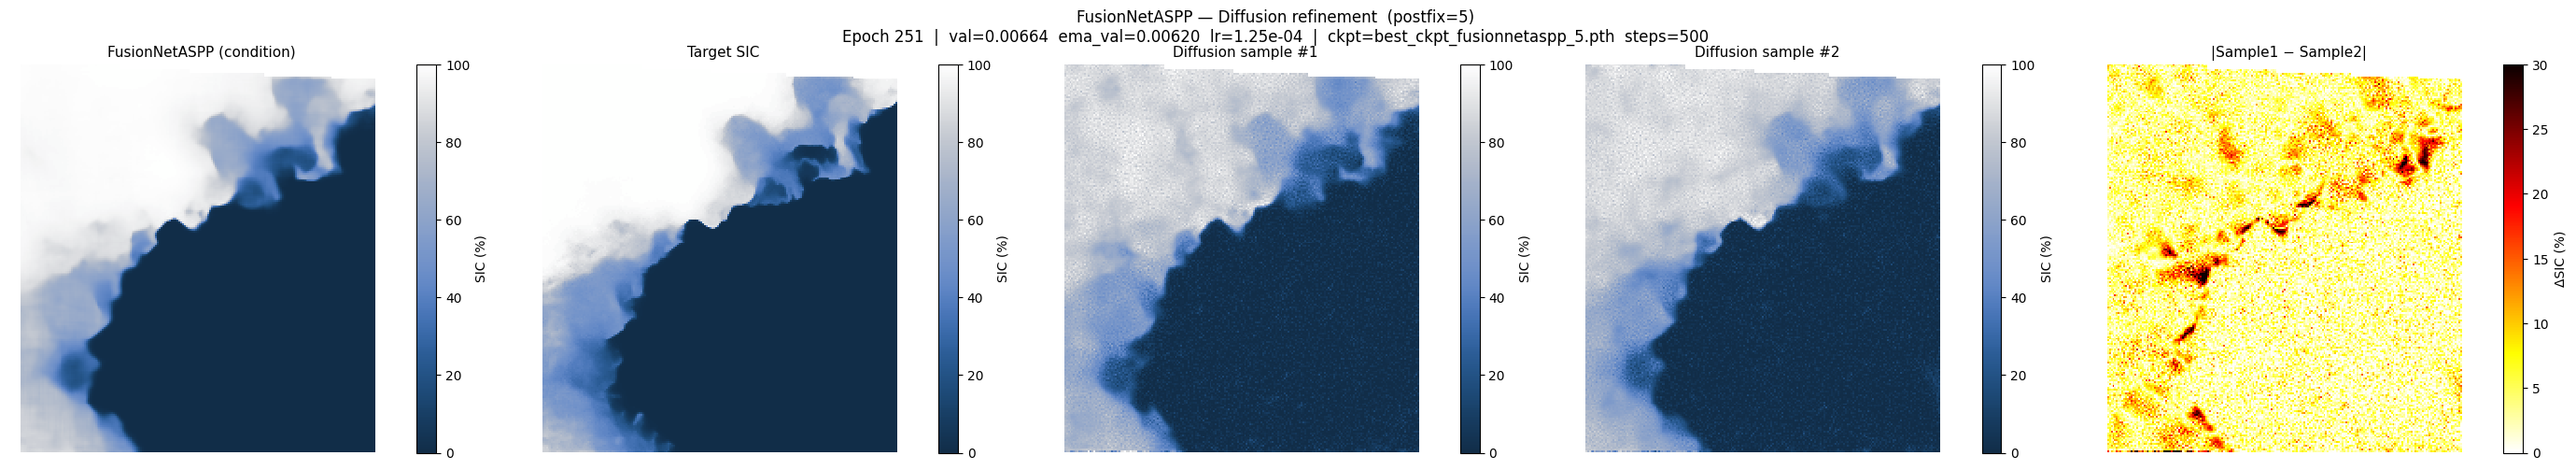

FusionNetASPP MAE : 3.44%
Diffusion MAE     : 7.36%


In [10]:
# ── Load saved samples (fast path) or fall back to live tensors ───────────────
if os.path.exists(SAMPLE_PATH):
    data     = np.load(SAMPLE_PATH)
    sic_raw  = data['sic_raw']
    y_raw    = data['y_raw']
    est1_raw = data['x_estim']   # in [0,1]
    est2_raw = data['x_estim2']  # in [0,1]
    mask_raw = data['mask_raw'].astype(bool)
    print(f'Loaded from {SAMPLE_PATH}')
else:
    sic_raw  = sic[SAMPLE_IDX, 0].cpu().numpy()
    y_raw    = y[SAMPLE_IDX, 0].detach().cpu().numpy()
    est1_raw = x_estim[SAMPLE_IDX,  0].detach().cpu().numpy()
    est2_raw = x_estim2[SAMPLE_IDX, 0].detach().cpu().numpy()
    mask_raw = mask[SAMPLE_IDX, 0].cpu().numpy().astype(bool)

plot_mask = mask_raw | (sic_raw >= SIC_SENTINEL_MIN)

sic_np   = np.where(plot_mask, np.nan, sic_raw)
y_np     = np.where(plot_mask, np.nan, np.clip(y_raw, 0, 100))
# Scale [0,1] → [0,100] for display
est1_np  = np.where(plot_mask, np.nan, np.clip(est1_raw * 100, 0, 100))
est2_np  = np.where(plot_mask, np.nan, np.clip(est2_raw * 100, 0, 100))
diff_np  = np.where(plot_mask, np.nan, np.abs(est1_np - est2_np))

# ── Colormap ──────────────────────────────────────────────────────────────────
try:
    import cmcrameri as cmc
    def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
        return mcolors.LinearSegmentedColormap.from_list(
            f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
            cmap(np.linspace(minval, maxval, n)))
    sic_cmap = truncate_colormap(cmc.cm.oslo, minval=0.2, maxval=1, n=100)
except ImportError:
    sic_cmap = plt.cm.Blues_r.copy()
    sic_cmap.set_bad('lightgray')

# ── Subtitle from checkpoint info ─────────────────────────────────────────────
_epoch     = diff_info['epoch']
_val       = diff_info['val_loss']
_ema_val   = diff_info['ema_val_loss']
_lr        = _h['lr'][_h['epoch'].index(_epoch)] if _h and _epoch in _h['epoch'] else float('nan')
_ckpt_name = os.path.basename(BEST_CKPT if os.path.exists(BEST_CKPT) else DIFF_CKPT)
subtitle   = (f'Epoch {_epoch}  |  val={_val:.5f}  ema_val={_ema_val:.5f}  '
              f'lr={_lr:.2e}  |  ckpt={_ckpt_name}  steps={NUM_STEPS}')

# ── 5-panel plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(28, 5))
panels = [
    (y_np,    f'{mdl_cls.name} (condition)', sic_cmap, 0, 100, 'SIC (%)'),
    (sic_np,  'Target SIC',                  sic_cmap, 0, 100, 'SIC (%)'),
    (est1_np, 'Diffusion sample #1',          sic_cmap, 0, 100, 'SIC (%)'),
    (est2_np, 'Diffusion sample #2',          sic_cmap, 0, 100, 'SIC (%)'),
    (diff_np, '|Sample1 − Sample2|',          'hot_r',  0,  30, 'ΔSIC (%)'),
]
for ax, (arr, title, cm, vn, vx, label) in zip(axes, panels):
    im = ax.imshow(arr, cmap=cm, vmin=vn, vmax=vx, interpolation='nearest')
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, label=label)

plt.suptitle(f'{mdl_cls.name} — Diffusion refinement  (postfix={postfix})\n{subtitle}', fontsize=12)
plt.tight_layout()
plt.show()

# ── MAE comparison ────────────────────────────────────────────────────────────
fusion_mae = np.nanmean(np.abs(y_np - sic_np))
diff_mae   = np.nanmean(np.abs(est1_np - sic_np))
print(f'FusionNetASPP MAE : {fusion_mae:.2f}%')
print(f'Diffusion MAE     : {diff_mae:.2f}%')

Loaded from /dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/outputs/diffusion/samples_fusionnetaspp_5_idx2.npz


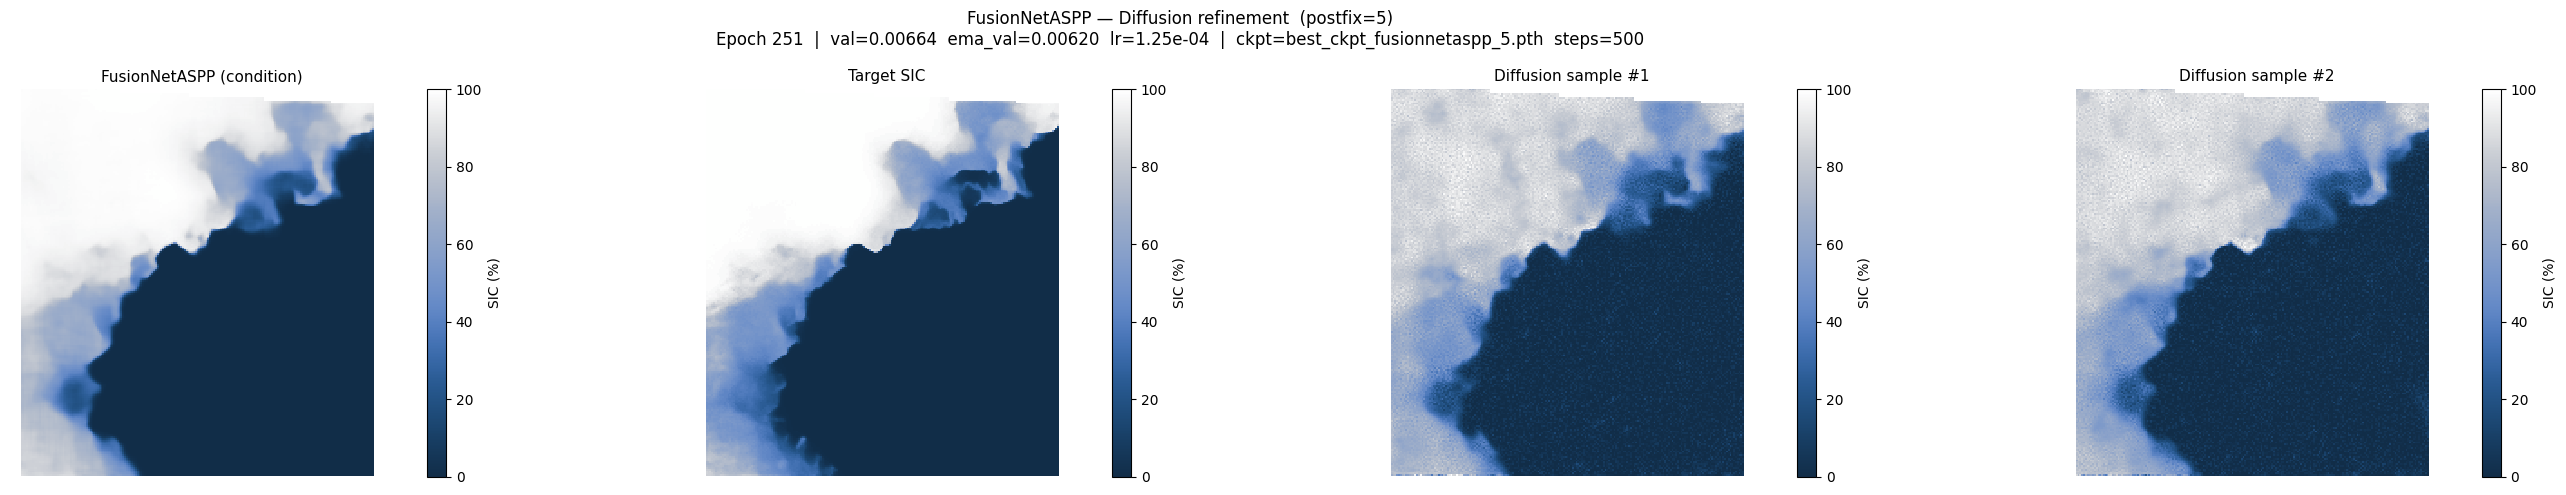

In [11]:
sample_path = f'{OUTPUT_DIR}/samples_{mdl_cls.name.lower()}_{postfix}_idx{SAMPLE_IDX}.npz'

# ── Load saved samples (fast path) or fall back to live tensors ───────────────
if os.path.exists(SAMPLE_PATH):
    data     = np.load(SAMPLE_PATH)
    sic_raw  = data['sic_raw']
    y_raw    = data['y_raw']
    est1_raw = data['x_estim']   # in [0,1]
    est2_raw = data['x_estim2']  # in [0,1]
    mask_raw = data['mask_raw'].astype(bool)
    print(f'Loaded from {SAMPLE_PATH}')
else:
    sic_raw  = sic[SAMPLE_IDX, 0].cpu().numpy()
    y_raw    = y[SAMPLE_IDX, 0].detach().cpu().numpy()
    est1_raw = x_estim[SAMPLE_IDX,  0].detach().cpu().numpy()
    est2_raw = x_estim2[SAMPLE_IDX, 0].detach().cpu().numpy()
    mask_raw = mask[SAMPLE_IDX, 0].cpu().numpy().astype(bool)

plot_mask = mask_raw | (sic_raw >= SIC_SENTINEL_MIN)

sic_np   = np.where(plot_mask, np.nan, sic_raw)
y_np     = np.where(plot_mask, np.nan, np.clip(y_raw, 0, 100))
# Scale [0,1] → [0,100] for display
est1_np  = np.where(plot_mask, np.nan, np.clip(est1_raw * 100, 0, 100))
est2_np  = np.where(plot_mask, np.nan, np.clip(est2_raw * 100, 0, 100))

# ── Colormap ──────────────────────────────────────────────────────────────────
try:
    import cmcrameri as cmc
    def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
        return mcolors.LinearSegmentedColormap.from_list(
            f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
            cmap(np.linspace(minval, maxval, n)))
    sic_cmap = truncate_colormap(cmc.cm.oslo, minval=0.2, maxval=1, n=100)
except ImportError:
    sic_cmap = plt.cm.Blues_r.copy()
    sic_cmap.set_bad('lightgray')

# ── Subtitle from checkpoint info ─────────────────────────────────────────────
_epoch     = diff_info['epoch']
_val       = diff_info['val_loss']
_ema_val   = diff_info['ema_val_loss']
_lr        = _h['lr'][_h['epoch'].index(_epoch)] if _h and _epoch in _h['epoch'] else float('nan')
_ckpt_name = os.path.basename(BEST_CKPT if os.path.exists(BEST_CKPT) else DIFF_CKPT)
subtitle   = (f'Epoch {_epoch}  |  val={_val:.5f}  ema_val={_ema_val:.5f}  '
              f'lr={_lr:.2e}  |  ckpt={_ckpt_name}  steps={NUM_STEPS}')

# ── 4-panel plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(28, 5))
panels = [
    (y_np,    f'{mdl_cls.name} (condition)', sic_cmap, 0, 100, 'SIC (%)'),
    (sic_np,  'Target SIC',                  sic_cmap, 0, 100, 'SIC (%)'),
    (est1_np, 'Diffusion sample #1',          sic_cmap, 0, 100, 'SIC (%)'),
    (est2_np, 'Diffusion sample #2',          sic_cmap, 0, 100, 'SIC (%)'),
]
for ax, (arr, title, cm, vn, vx, label) in zip(axes, panels):
    im = ax.imshow(arr, cmap=cm, vmin=vn, vmax=vx, interpolation='nearest')
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, label=label)

plt.suptitle(f'{mdl_cls.name} — Diffusion refinement  (postfix={postfix})\n{subtitle}', fontsize=12)
plt.tight_layout()
plt.show()

## 6 — Multi-sample uncertainty map

In [ ]:
N_SAMPLES = 50
print(f'Collecting {N_SAMPLES} samples ...')
samples = []
for i in range(N_SAMPLES):
    s = Euler_Maruyama_sampler(
        score_model, marginal_prob_std_fn, diffusion_coeff_fn,
        y_cond, batch_size=sic.shape[0],
        num_steps=NUM_STEPS, device=str(device), verbose=False,
    )
    # Scale [0,1] → [0,100] and clip
    samples.append(np.clip(s[SAMPLE_IDX, 0].detach().cpu().numpy() * 100, 0, 100))
    print(f'  {i+1}/{N_SAMPLES}', end='\r')

samples  = np.stack(samples)   # [N, H, W] in [0,100]
mean_sic = np.where(plot_mask, np.nan, np.clip(np.nanmean(samples, axis=0), 0, 100))
std_sic  = np.where(plot_mask, np.nan, np.nanstd(samples, axis=0))
print(f'\nDone. Shape: {samples.shape}')

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
panels = [
    (sic_np,   'Target SIC',                     sic_cmap, 0, 100, 'SIC (%)'),
    (y_np,     f'Condition ({mdl_cls.name})',     sic_cmap, 0, 100, 'SIC (%)'),
    (mean_sic, f'Diffusion mean (N={N_SAMPLES})', sic_cmap, 0, 100, 'SIC (%)'),
    (std_sic,  'Std dev (uncertainty)',           'YlOrRd', 0,  15, 'SIC (%)'),
]
for ax, (arr, title, cm, vn, vx, label) in zip(axes, panels):
    im = ax.imshow(arr, cmap=cm, vmin=vn, vmax=vx, interpolation='nearest')
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, label=label)

plt.suptitle(f'Uncertainty — {N_SAMPLES} samples  (postfix={postfix})', fontsize=13)
plt.tight_layout()
plt.show()

valid = ~np.isnan(std_sic)
print(f'Mean std (valid pixels): {std_sic[valid].mean():.2f}%')
print(f'Max  std (valid pixels): {std_sic[valid].max():.2f}%')

## 7 — CRPS & Reliability diagram

In [ ]:
valid_px = ~np.isnan(sic_np)
obs      = sic_np[valid_px]
ens      = samples[:, valid_px]   # [N, P] in [0,100]

def crps_ensemble(obs, ens):
    mae    = np.mean(np.abs(ens - obs[None, :]), axis=0)
    spread = np.mean(np.abs(ens[:, None, :] - ens[None, :, :]), axis=(0, 1))
    return mae - 0.5 * spread

crps = crps_ensemble(obs, ens)
print(f'Mean CRPS              : {crps.mean():.3f}%')
print(f'FusionNet MAE (sample) : {np.nanmean(np.abs(y_np - sic_np)):.3f}%')
print(f'Diffusion mean MAE     : {np.nanmean(np.abs(mean_sic - sic_np)):.3f}%')

Mean CRPS              : 4.754%
FusionNet MAE (sample) : 3.436%
Diffusion mean MAE     : 6.644%


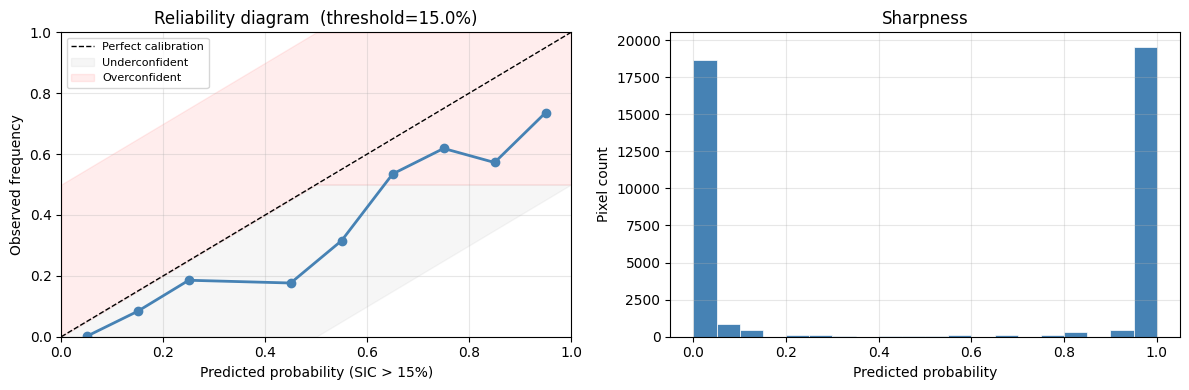

In [ ]:
threshold  = 15.0
pred_prob  = (ens > threshold).mean(axis=0)
obs_binary = (obs  > threshold).astype(float)

bins = np.linspace(0, 1, 11)
bin_centers, obs_freq = [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    m = (pred_prob >= lo) & (pred_prob < hi)
    if m.sum() > 50:
        bin_centers.append((lo + hi) / 2)
        obs_freq.append(obs_binary[m].mean())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot([0,1], [0,1], 'k--', label='Perfect calibration', linewidth=1)
axes[0].plot(bin_centers, obs_freq, 'o-', color='steelblue', linewidth=2, markersize=6)
axes[0].fill_between([0,0.5,1], [0,0,0.5], [0,0.5,0.5], alpha=0.07, color='gray', label='Underconfident')
axes[0].fill_between([0,0.5,1], [0,0.5,0.5], [0.5,1,1], alpha=0.07, color='red',  label='Overconfident')
axes[0].set_xlim(0,1); axes[0].set_ylim(0,1)
axes[0].set_xlabel('Predicted probability (SIC > 15%)')
axes[0].set_ylabel('Observed frequency')
axes[0].set_title(f'Reliability diagram  (threshold={threshold}%)')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].hist(pred_prob, bins=20, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Predicted probability')
axes[1].set_ylabel('Pixel count')
axes[1].set_title('Sharpness')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── CRPS ──────────────────────────────────────────────────────────────────────
# For a deterministic model, CRPS = MAE — use FusionNetASPP as baseline
# For the diffusion ensemble, CRPS measures the full predictive distribution

valid_px = ~np.isnan(sic_np)
obs      = sic_np[valid_px]        # [P] observed SIC in [0,100]
ens      = samples[:, valid_px]    # [N, P] ensemble samples in [0,100]

def crps_ensemble(obs, ens):
    """
    CRPS for an ensemble forecast.
    CRPS = E|X - y| - 0.5 * E|X - X'|
    where X, X' are independent draws from the forecast distribution.
    Units match the input (% SIC here).
    """
    mae    = np.mean(np.abs(ens - obs[None, :]), axis=0)          # [P]
    spread = np.mean(np.abs(ens[:, None, :] - ens[None, :, :]),   # [P]
                     axis=(0, 1))
    return mae - 0.5 * spread                                      # [P]

crps = crps_ensemble(obs, ens)

fusion_mae    = np.nanmean(np.abs(y_np[valid_px] - obs))
diff_mean_mae = np.nanmean(np.abs(mean_sic[valid_px] - obs))

print('─' * 42)
print('  VERIFICATION SCORES')
print('─' * 42)
print(f'  FusionNetASPP MAE   : {fusion_mae:.3f}%  (= CRPS for deterministic)')
print(f'  Diffusion mean MAE  : {diff_mean_mae:.3f}%')
print(f'  Diffusion CRPS      : {crps.mean():.3f}%  (N={len(ens)} samples)')
print(f'  CRPS skill score    : {1 - crps.mean() / fusion_mae:+.3f}')
print('─' * 42)
print(f'  Note: CRPS < FusionNetASPP MAE means the probabilistic')
print(f'  forecast outperforms the deterministic baseline overall.')

──────────────────────────────────────────
  VERIFICATION SCORES
──────────────────────────────────────────
  FusionNetASPP MAE   : 3.436%  (= CRPS for deterministic)
  Diffusion mean MAE  : 6.644%
  Diffusion CRPS      : 4.754%  (N=20 samples)
  CRPS skill score    : -0.383
──────────────────────────────────────────
  Note: CRPS < FusionNetASPP MAE means the probabilistic
  forecast outperforms the deterministic baseline overall.
